# Alzheimer's Disease Prediction: exploratory notebook
EDA, then Random Forest with SMOTE, and an XGBoost + SMOTE grid-search pipeline.

**Before running:** download `alzheimers_disease_data.csv` from [Kaggle](https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset) and place it in this folder.

> The XGBoost grid below covers 138,240 combinations and was not run to completion here. The final team pipeline (feature engineering, Decision Tree, SVM, tuned XGBoost) is summarised in the README.

Load the dataset

In [7]:
import pandas as pd
df = pd.read_csv(r'alzheimers_disease_data.csv')
print(df.head())

   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorientation  \
0     

Shape of the dataset

In [8]:
print(df.shape)

(2149, 35)


Display Column Header only

In [9]:
print(df.columns.tolist())

['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']


Check for any missing value

In [10]:
print(df.isnull().sum())

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

Drop any non-numeric column

In [11]:
df_cleaned = df.drop(columns=['DoctorInCharge','PatientID'])
print(df_cleaned)

      Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0      73       0          0               2  22.927749        0   
1      89       0          0               0  26.827681        0   
2      73       0          3               1  17.795882        0   
3      74       1          0               1  33.800817        1   
4      89       0          0               0  20.716974        0   
...   ...     ...        ...             ...        ...      ...   
2144   61       0          0               1  39.121757        0   
2145   75       0          0               2  17.857903        0   
2146   77       0          0               1  15.476479        0   
2147   78       1          3               1  15.299911        0   
2148   72       0          0               2  33.289738        0   

      AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
0              13.297218          6.327112     1.347214      9.025679  ...   
1               4.542524   

Histogram

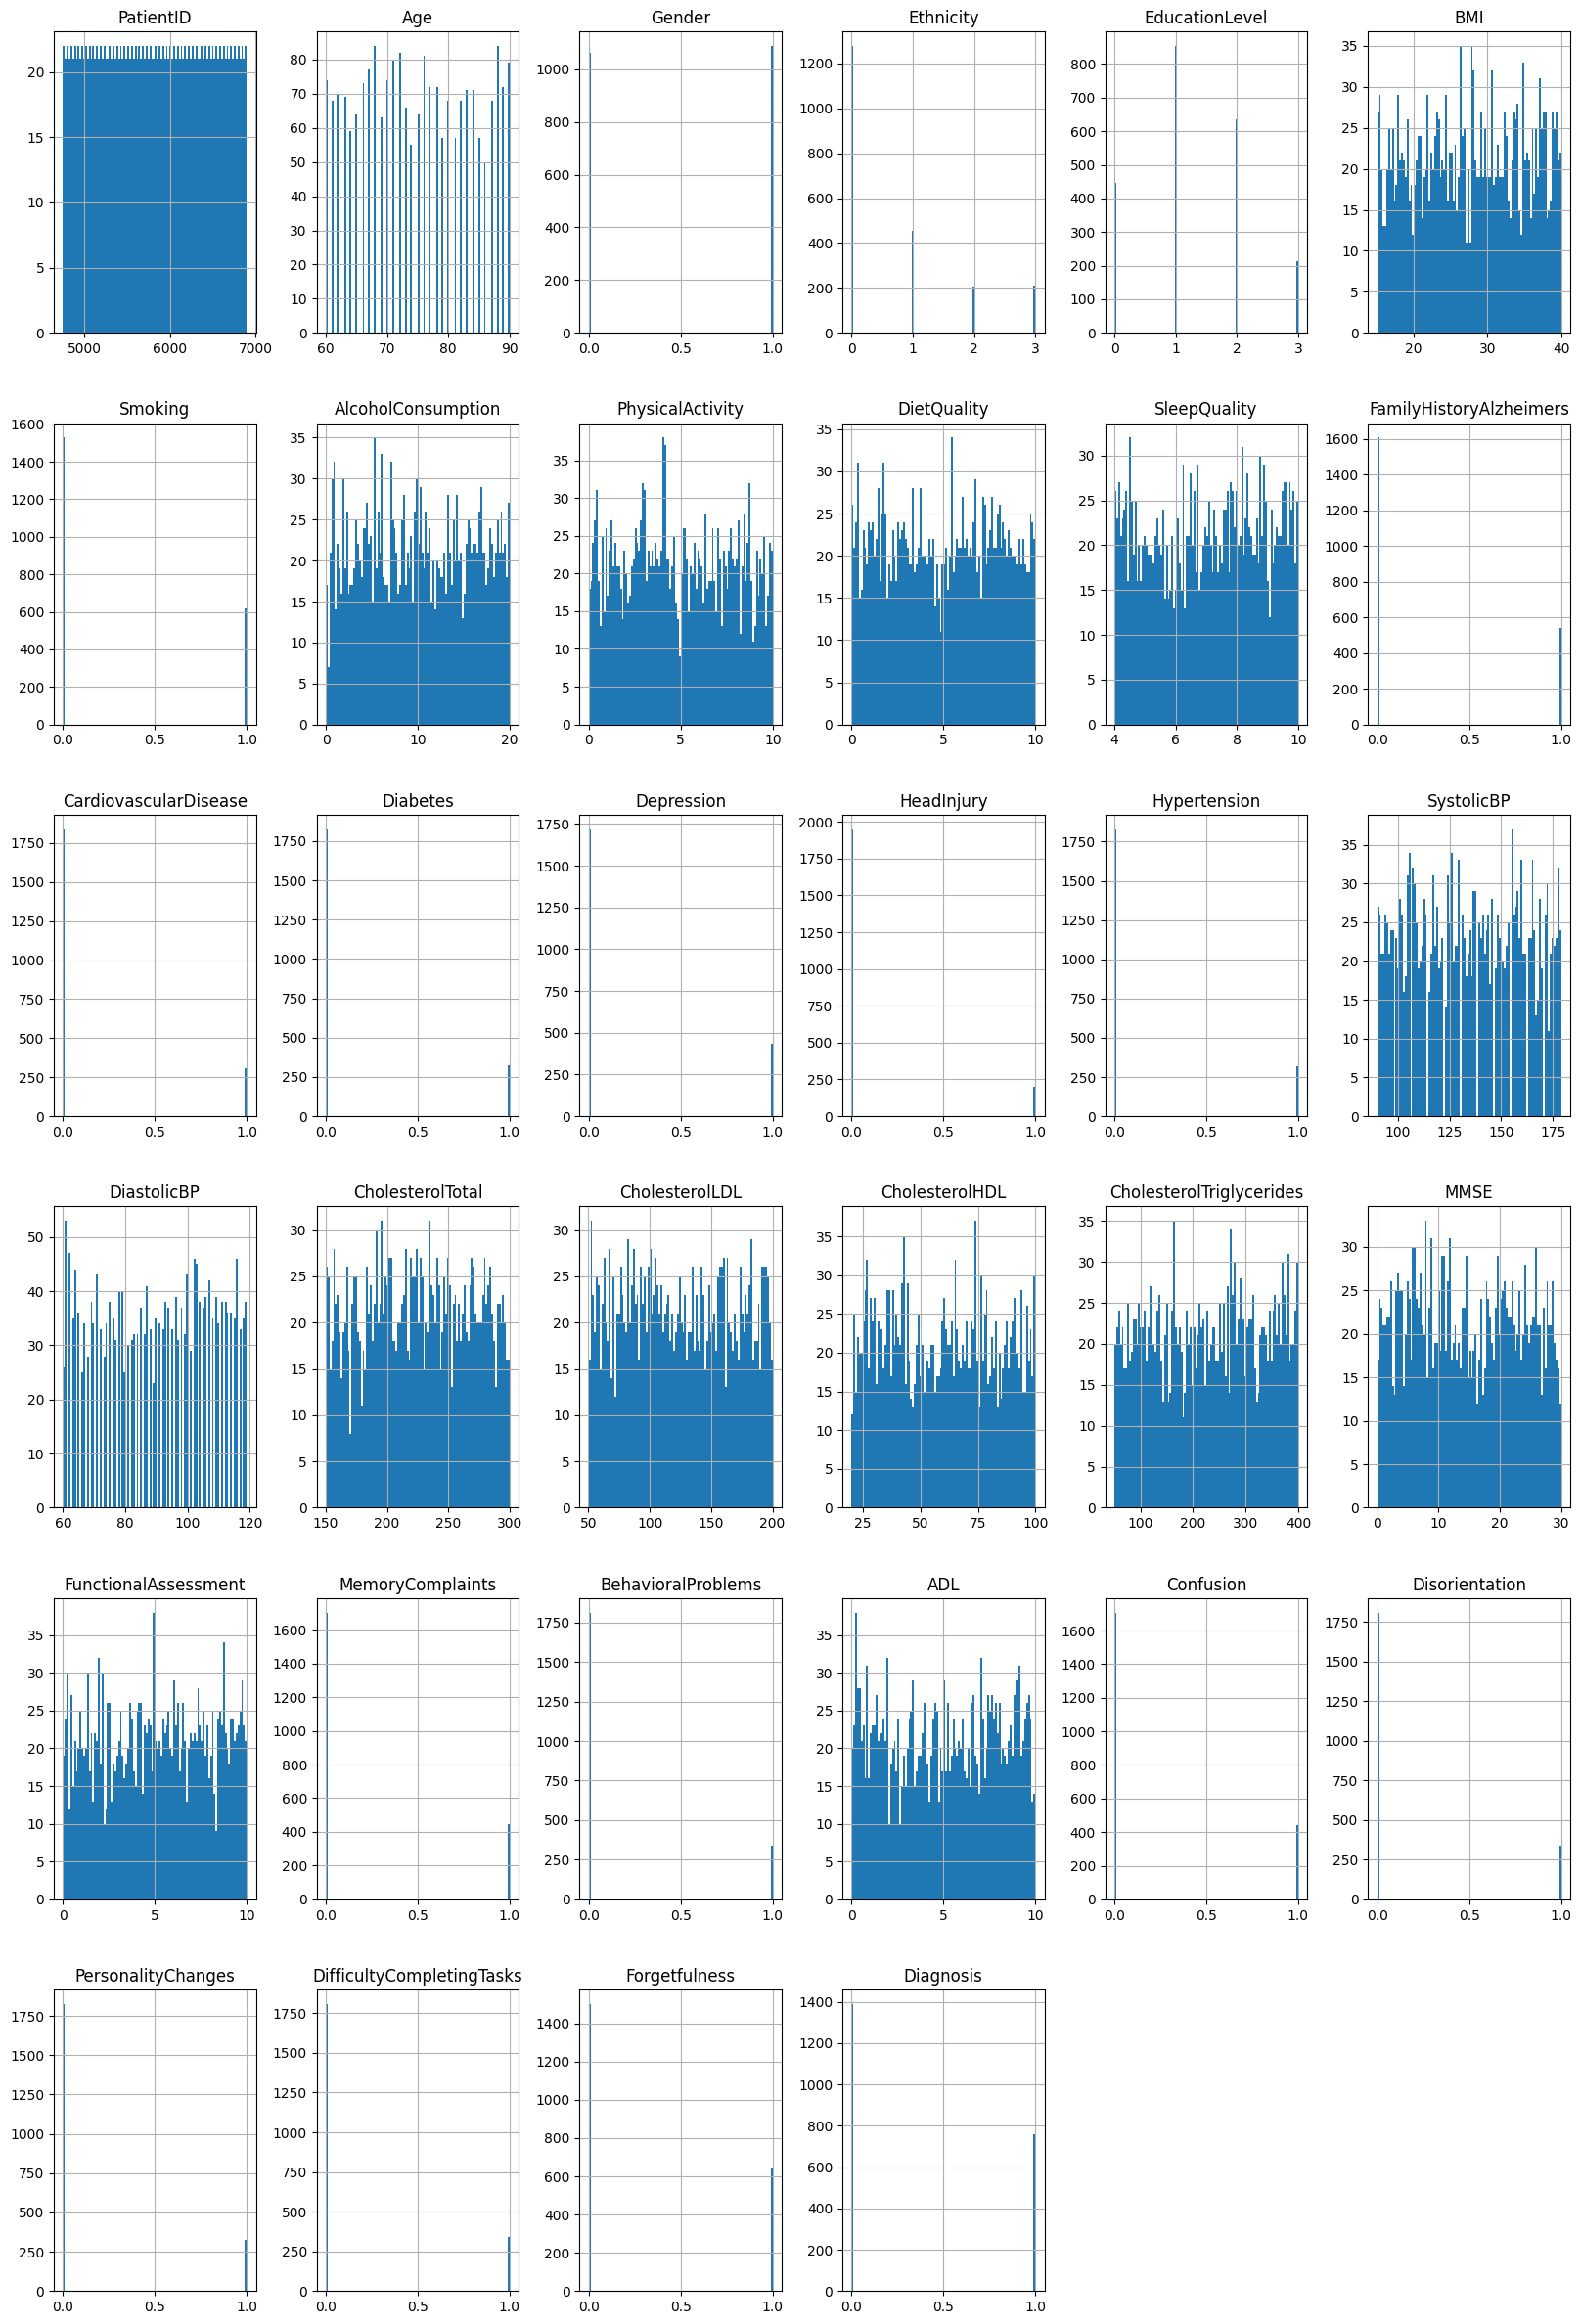

In [12]:
import matplotlib.pyplot as plt
df.hist(bins=100, figsize=(20,30))
plt.show()

Correlation Matrix (numerical features)

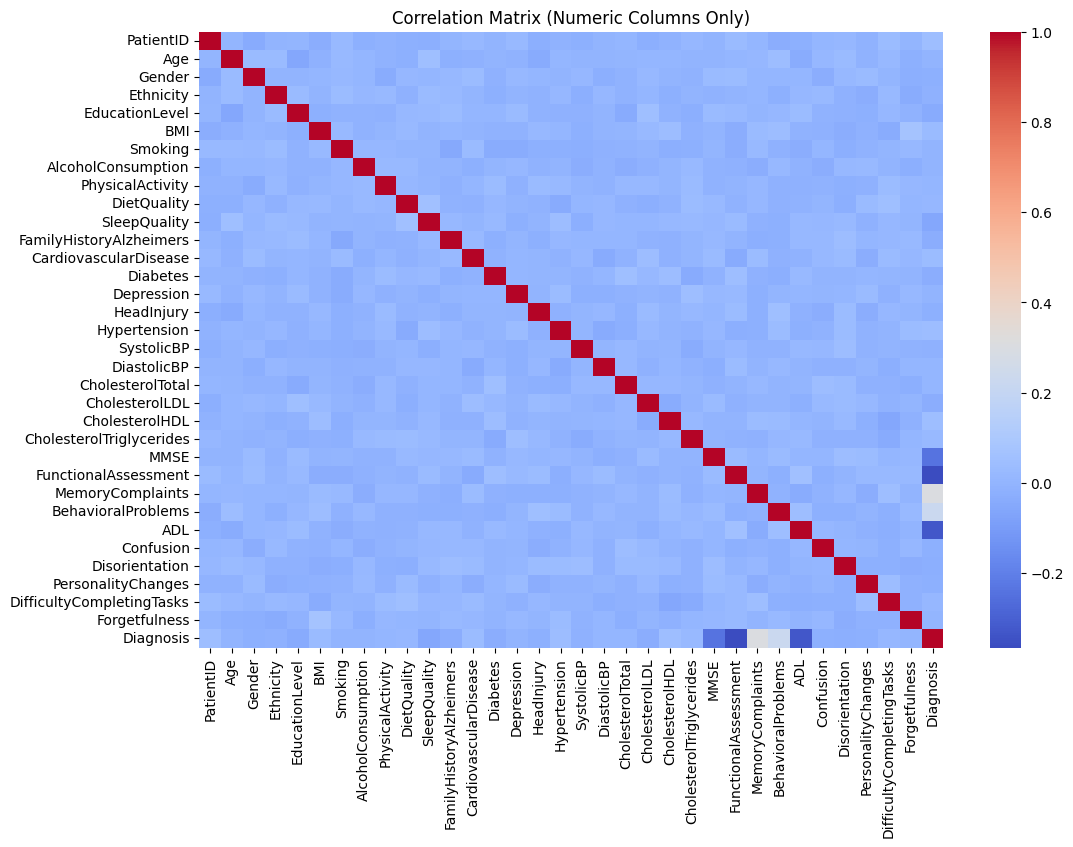

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Plot correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', fmt='.0f')
plt.title("Correlation Matrix (Numeric Columns Only)")
plt.show()

Target Variable

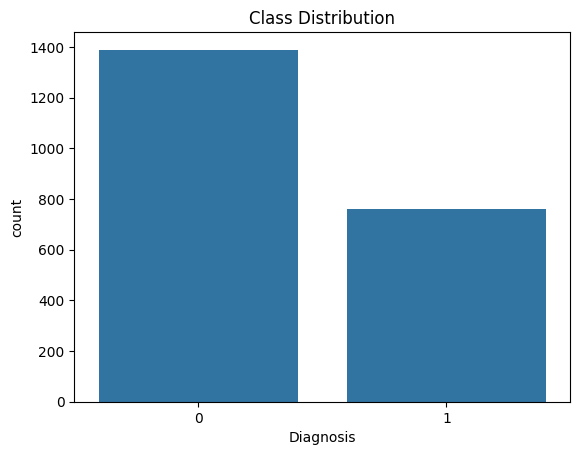

Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [14]:
sns.countplot(x='Diagnosis', data=df)
plt.title("Class Distribution")
plt.show()
print(df['Diagnosis'].value_counts())

In [15]:
non_numeric = df.apply(lambda col: pd.to_numeric(col, errors='coerce').isnull().any())
print("Non-numeric columns:")
print(non_numeric[non_numeric])

Non-numeric columns:
DoctorInCharge    True
dtype: bool


Machine Learning Model 1: Random Forest with SMOTE

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

In [17]:
# Features and target
X = df_cleaned.drop(columns=['Diagnosis'])  # Replace with actual feature columns
y = df_cleaned['Diagnosis']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Before SMOTE: Check class distribution
print("Before SMOTE:", Counter(y_train))

Before SMOTE: Counter({0: 1111, 1: 608})


In [19]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# After SMOTE: Check new class distribution
print("After SMOTE:", Counter(y_res))

After SMOTE: Counter({0: 1111, 1: 1111})


In [20]:
# Train a classifier on resampled data
model = RandomForestClassifier(random_state=42)
model.fit(X_res, y_res)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       278
           1       0.92      0.85      0.88       152

    accuracy                           0.92       430
   macro avg       0.92      0.90      0.91       430
weighted avg       0.92      0.92      0.92       430

Confusion Matrix:
 [[267  11]
 [ 23 129]]


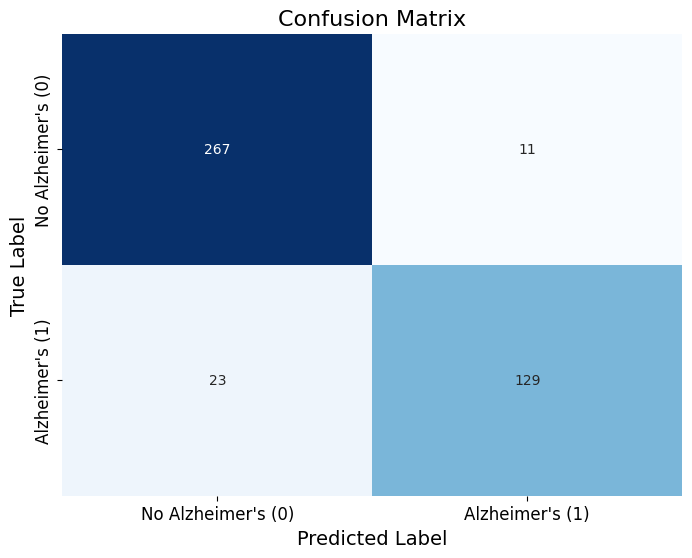

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Alzheimer\'s (0)', 'Alzheimer\'s (1)'],
            yticklabels=['No Alzheimer\'s (0)', 'Alzheimer\'s (1)'])

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

XGBoost

In [ ]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.model_selection import GridSearchCV

# Define pipeline with SMOTE and XGBoost
pipeline = imbpipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# Expanded hyperparameter grid
param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__max_depth': [3, 4, 5, 6],
    'xgb__min_child_weight': [1, 2, 3, 5],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.2, 0.5],
    'xgb__reg_alpha': [0, 0.001, 0.01, 0.1, 1],
    'xgb__reg_lambda': [0.1, 1, 1.5, 2]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=2,
    n_jobs=-1  # Uses all available CPU cores
)

# Fit on training data
grid_search.fit(X_train, y_train)

After Training, get the Best Model

In [ ]:
# Best parameters found
print("Best Parameters:", grid_search.best_params_)

# Predict on test set
y_pred = grid_search.predict(X_test)

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best XGBoost Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()